In [1]:
import warnings
from scipy.stats import randint, uniform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

# 0. 全局风格
np.random.seed(42)

warnings.filterwarnings("ignore")

%matplotlib inline

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [6]:
# 1. 生成一个数据集
n = 4000
x0 = np.random.uniform(-3, 3, n)
x1 = np.random.uniform(-2, 2, n)
x2 = np.random.normal(0, 1, n)
x3 = np.random.uniform(-1, 1, n)
x4 = np.random.uniform(0, 2, n)
x5 = np.random.normal(0, 1, n)
x6 = np.random.normal(0, 1, n)
x7 = np.random.uniform(-3, 3, n)
x8 = np.random.uniform(-2, 2, n)  # 再加个特征

# 真实函数：非线性 + 交互 + 阈值效应
f = (
    8 * np.sin(x0)
    + 0.8 * (x1 ** 2)
    - 6 * np.exp(-(x2 ** 2))
    + 5 * (x3 > 0).astype(float) * x4
    + 3 * x5 * x6
    + 4 * np.abs(x7)
    + 2 * np.sin(np.pi * x1 * x3)
    + 0.5 * x8 ** 3 / 6.0
)

# 异方差噪声（x0越大噪声越大；x3>0时受x4影响更强）
sigma = 1.0 + 0.7 * np.abs(x0) + 0.5 * (x3 > 0).astype(float) * x4
noise = np.random.normal(0, sigma, n)

y = f + noise

# 注入少量异常点
outlier_idx = np.random.choice(np.arange(n), size=int(0.01*n), replace=False)
y[outlier_idx] += np.random.choice([-1, 1], size=len(outlier_idx)) * np.random.uniform(10, 18, size=len(outlier_idx))

# 组装DataFrame
X = pd.DataFrame({
    "x0": x0, "x1": x1, "x2": x2, "x3": x3, "x4": x4,
    "x5": x5, "x6": x6, "x7": x7, "x8": x8
})
y = pd.Series(y, name="y")
X

,x0,x1,x2,x3,x4,x5,x6,x7,x8
0,-1.664451,0.584453,0.343165,-0.215156,1.437054,-1.524384,0.799131,-0.742548,1.089037
1,0.429129,0.683876,0.491309,0.543735,0.945710,0.891956,0.648573,0.128670,0.195821
2,1.790383,0.818662,-1.020547,-0.471616,0.522515,-0.012957,-0.025385,0.402187,1.390683
3,0.095580,-0.109578,-1.212312,0.381637,0.110971,0.109370,-0.452445,1.113452,-0.020825
4,1.745393,0.314135,0.674443,0.483284,0.090418,-0.082384,0.316649,-2.745683,1.148611
...,...,...,...,...,...,...,...,...,...
3995,-0.810211,-1.447707,-1.616294,0.488823,1.707888,1.156054,0.695031,2.004295,-1.307267
3996,0.571358,0.922642,-0.474838,0.766860,0.341307,-0.103338,1.649513,-0.489009,0.939986
3997,-1.194639,-1.954320,-1.244981,0.147448,0.584422,-0.877319,0.612721,-2.148878,-1.254671
3998,2.148421,0.518047,-1.577669,-0.008717,0.349623,-0.029358,-0.387923,-0.555625,-1.722305


In [7]:
# 2. 快速EDA：选4个特征做pairplot
sample_idx = np.random.choice(np.arange(n), size=600, replace=False)
X_s = X.iloc[sample_idx][["x0", "x1", "x2", "x7"]].copy()
y_s = y.iloc[sample_idx].copy()
y_bin = pd.qcut(y_s, q=5, labels=["超低", "低", "中", "高", "超高"])
pp_df = X_s.copy()
pp_df["y_bin"] = y_bin

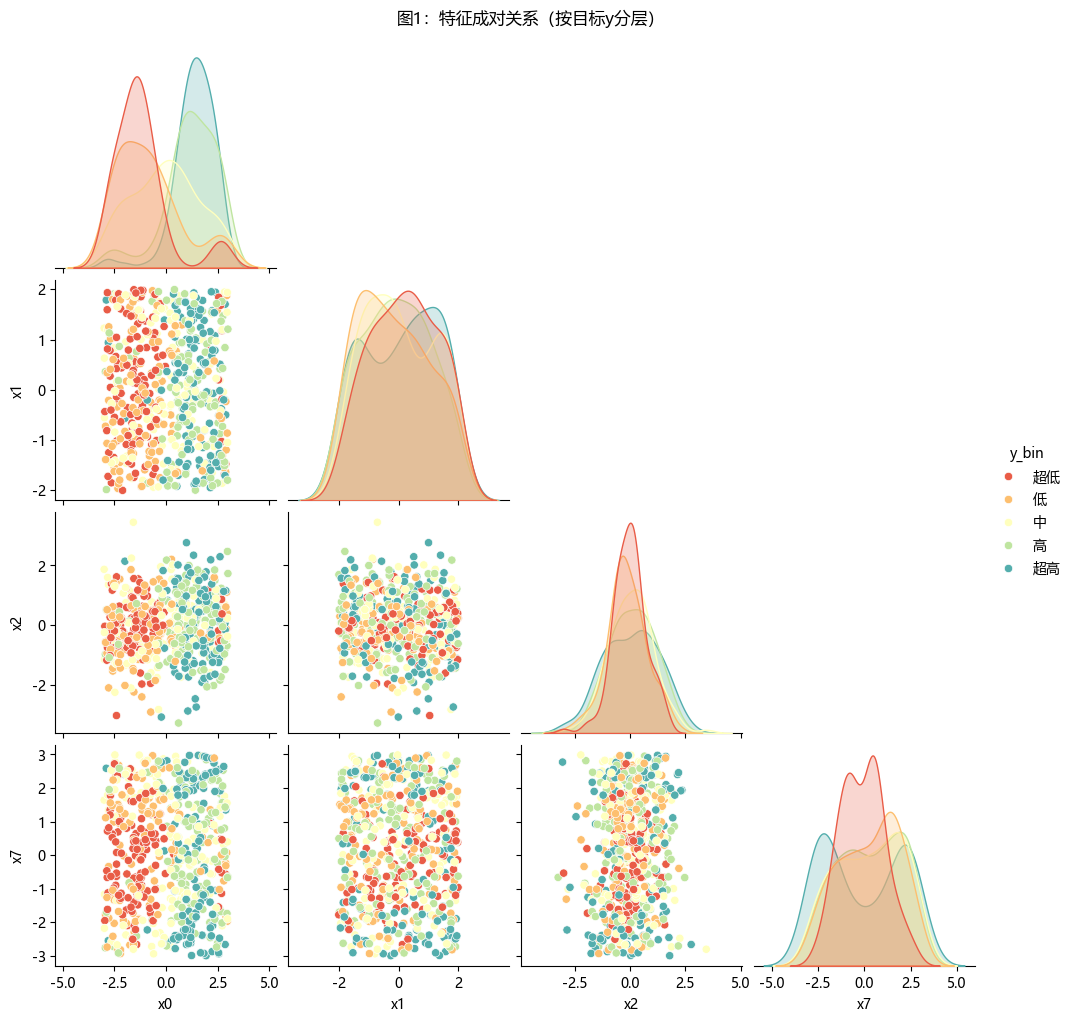

In [8]:
# 图1：Pairplot
sns.pairplot(pp_df, vars=["x0", "x1", "x2", "x7"], hue="y_bin",
             palette=sns.color_palette("Spectral", 5), diag_kind="kde", corner=True)
plt.suptitle("图1：特征成对关系（按目标y分层）", y=1.02)
plt.show()

In [9]:
# 3. 训练/测试划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 4. 基线随机森林模型（带oob）
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features=0.7,   # 回归中较小的max_features可以降低树相关性
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

# 基线评估
y_pred = rf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f"基线模型 - Test MSE: {mse:.3f}, MAE: {mae:.3f}, R^2: {r2:.3f}, OOB R^2: {rf.oob_score_:.3f}")

基线模型 - Test MSE: 22.570, MAE: 3.633, R^2: 0.721, OOB R^2: 0.715


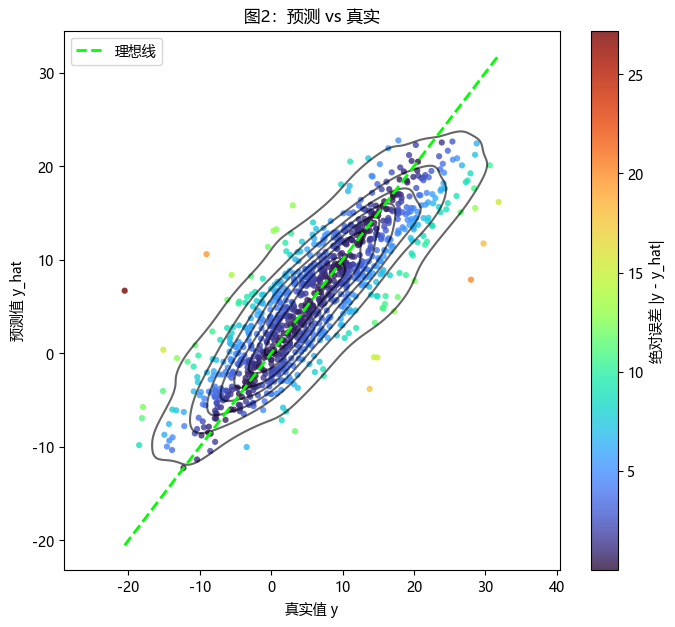

In [10]:
# 图2：预测 vs 真实（颜色=绝对误差；叠加核密度等高线）
fig, ax = plt.subplots(figsize=(8, 7))
abs_err = np.abs(y_test - y_pred)
sc = ax.scatter(y_test, y_pred, c=abs_err, cmap="turbo", s=20, alpha=0.8, edgecolor="none")
sns.kdeplot(x=y_test, y=y_pred, levels=8, color="k", linewidth=1.2, alpha=0.6, ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="lime", lw=2, linestyle="--", label="理想线")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("绝对误差 |y - y_hat|")
ax.set_xlabel("真实值 y")
ax.set_ylabel("预测值 y_hat")
ax.set_title("图2：预测 vs 真实")
ax.legend()
plt.show()

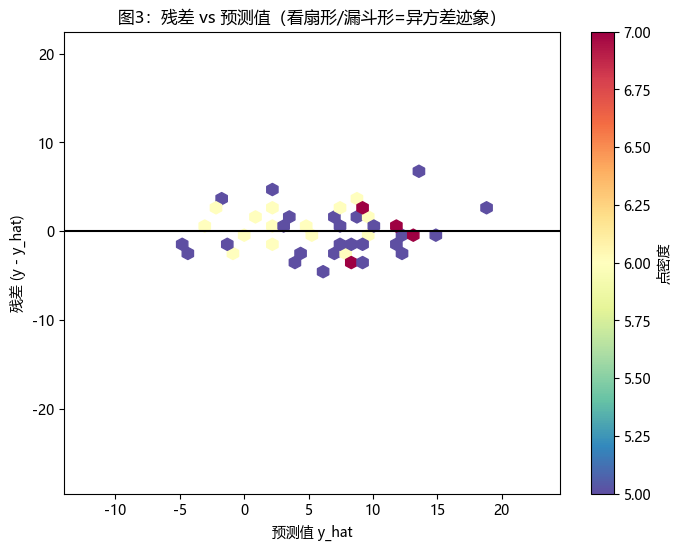

In [11]:
# 图3：残差 vs 预测值 的六边形密度图（检察异方差）
resid = y_test - y_pred
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(y_pred, resid, gridsize=40, cmap="Spectral_r", mincnt=5)
ax.axhline(0, color="black", lw=1.5)
cbar = plt.colorbar(hb, ax=ax)
cbar.set_label("点密度")
ax.set_xlabel("预测值 y_hat")
ax.set_ylabel("残差 (y - y_hat)")
ax.set_title("图3：残差 vs 预测值（看扇形/漏斗形=异方差迹象）")
plt.show()

In [12]:
# 5. 随机搜索调参（快速示意：可根据算力增大n_iter）

param_dist = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(5, 30),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 6),
    "max_features": uniform(0.4, 0.6),  # 0.4~1.0
    "bootstrap": [True],
}

rf_base = RandomForestRegressor(
    n_jobs=-1, random_state=42, oob_score=True
)
cv = KFold(n_splits=3, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    rf_base, param_distributions=param_dist,
    n_iter=20, scoring="neg_mean_squared_error",
    cv=cv, n_jobs=-1, verbose=1, random_state=42
)
rs.fit(X_train, y_train)
best_rf = rs.best_estimator_
print("随机搜索最优参数：", rs.best_params_)

y_pred_best = best_rf.predict(X_test)
print(f"调参后 - Test MSE: {mean_squared_error(y_test, y_pred_best):.3f}, "
      f"MAE: {mean_absolute_error(y_test, y_pred_best):.3f}, "
      f"R^2: {r2_score(y_test, y_pred_best):.3f}, "
      f"OOB R^2: {best_rf.oob_score_:.3f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
随机搜索最优参数： {'bootstrap': True, 'max_depth': 28, 'max_features': np.float64(0.6369289109053419), 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 792}
调参后 - Test MSE: 22.366, MAE: 3.614, R^2: 0.724, OOB R^2: 0.717


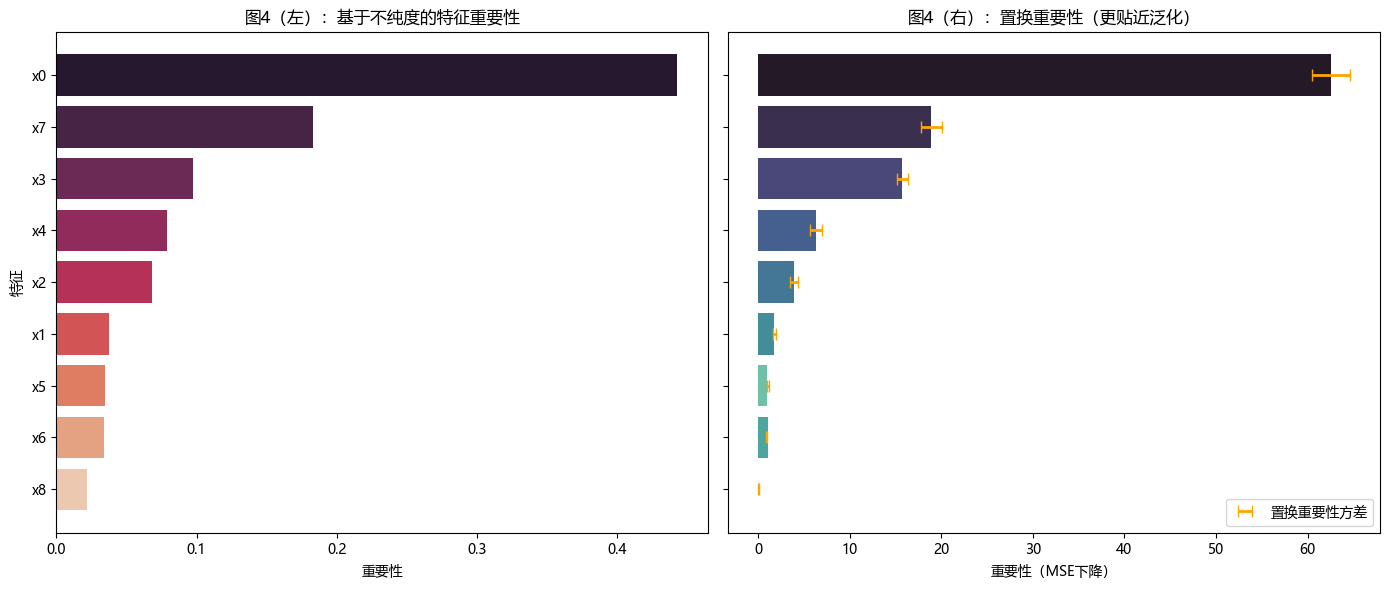

In [13]:
# 6. 特征重要性（Gini重要性 vs 置换重要性）
imp_gini = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

perm = permutation_importance(best_rf, X_test, y_test, scoring="neg_mean_squared_error",
                              n_repeats=10, random_state=42, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
imp_perm_err = pd.Series(perm.importances_std, index=X.columns).loc[imp_perm.index]

# 图4：两种重要性对比
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
sns.barplot(x=imp_gini.values, y=imp_gini.index, ax=axes[0],
            palette=sns.color_palette("rocket", n_colors=len(imp_gini)))
axes[0].set_title("图4（左）：基于不纯度的特征重要性")
axes[0].set_xlabel("重要性")
axes[0].set_ylabel("特征")

sns.barplot(x=imp_perm.values, y=imp_perm.index, ax=axes[1],
            palette=sns.color_palette("mako", n_colors=len(imp_perm)))
axes[1].errorbar(imp_perm.values, np.arange(len(imp_perm)), xerr=imp_perm_err.values,
                 fmt="none", ecolor="orange", elinewidth=2, capsize=4, label="置换重要性方差")
axes[1].legend()
axes[1].set_title("图4（右）：置换重要性（更贴近泛化）")
axes[1].set_xlabel("重要性（MSE下降）")
plt.tight_layout()
plt.show()

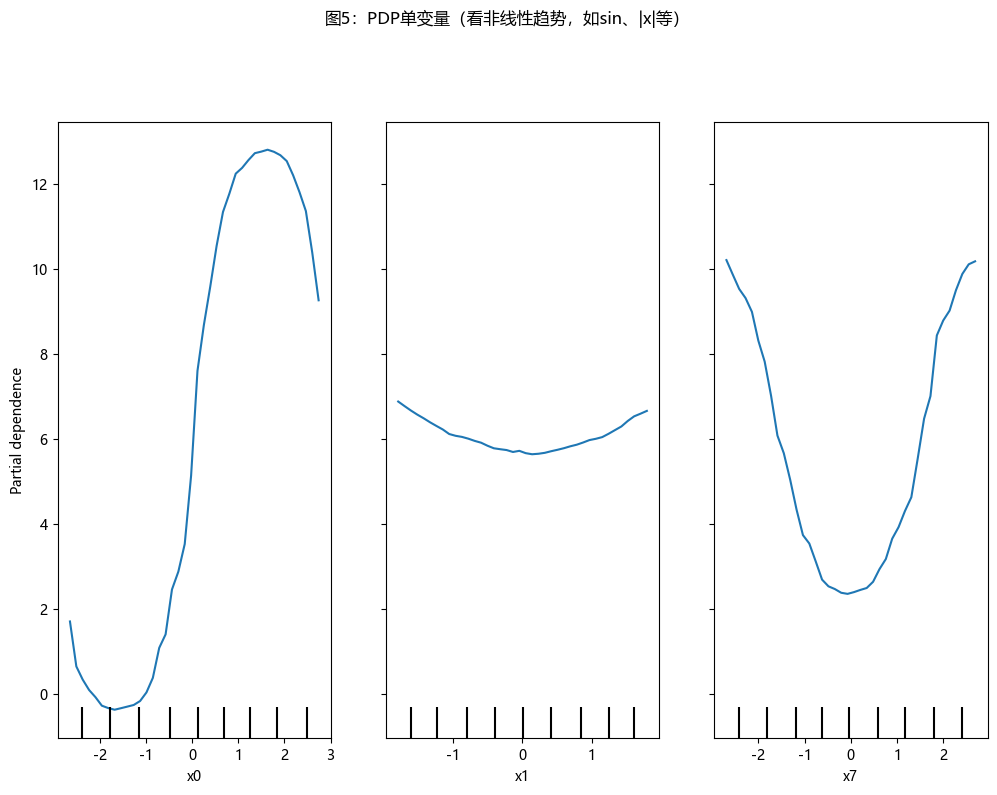

In [14]:
# 7. 部分依赖（PDP）：单变量与二维交互
features_1d = ["x0", "x1", "x7"]
fig, ax = plt.subplots(figsize=(12, 8))
display = PartialDependenceDisplay.from_estimator(
    best_rf, X_train, features=features_1d, grid_resolution=40,
    kind="average", ax=ax
)
plt.suptitle("图5：PDP单变量（看非线性趋势，如sin、|x|等）", y=1.02)
plt.show()

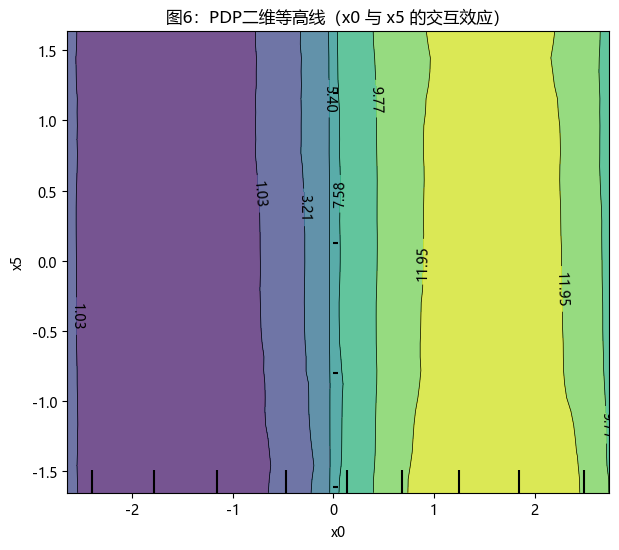

In [15]:
# 二维PDP：x0 与 x5 的交互
fig, ax = plt.subplots(figsize=(7, 6))
display2d = PartialDependenceDisplay.from_estimator(
    best_rf, X_train, features=[("x0", "x5")],
    grid_resolution=35, kind="average", ax=ax
)
plt.title("图6：PDP二维等高线（x0 与 x5 的交互效应）")
plt.show()

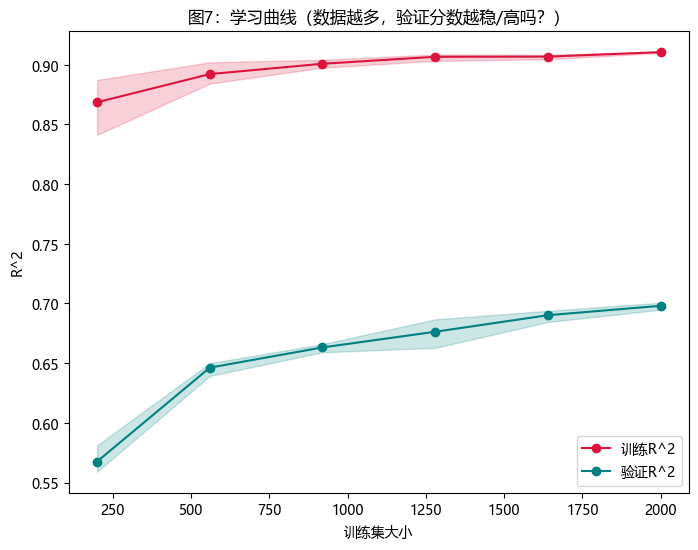

In [16]:
# 8. 学习曲线：数据量 vs 得分
train_sizes, train_scores, valid_scores = learning_curve(
    best_rf, X_train, y_train, cv=3, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1, shuffle=True, random_state=42
)
train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(train_sizes, train_mean, marker="o", color="crimson", label="训练R^2")
ax.plot(train_sizes, valid_mean, marker="o", color="teal", label="验证R^2")
ax.fill_between(train_sizes, train_scores.min(axis=1), train_scores.max(axis=1),
                alpha=0.2, color="crimson")
ax.fill_between(train_sizes, valid_scores.min(axis=1), valid_scores.max(axis=1),
                alpha=0.2, color="teal")
ax.set_xlabel("训练集大小")
ax.set_ylabel("R^2")
ax.set_title("图7：学习曲线（数据越多，验证分数越稳/高吗？）")
ax.legend()
plt.show()

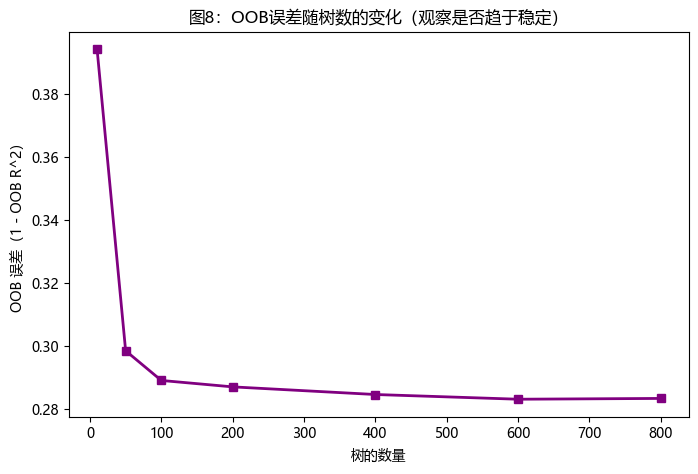

In [17]:
# 9. OOB误差 vs 森林规模（warm_start逐步增长）
ntrees_list = [10, 50, 100, 200, 400, 600, 800]
oob_r2_list = []
rf_oob = RandomForestRegressor(
    n_estimators=10, oob_score=True, bootstrap=True,
    max_depth=rs.best_params_.get("max_depth", None),
    min_samples_leaf=rs.best_params_.get("min_samples_leaf", 1),
    min_samples_split=rs.best_params_.get("min_samples_split", 2),
    max_features=rs.best_params_.get("max_features", 0.7),
    random_state=42, n_jobs=-1, warm_start=True
)
for M in ntrees_list:
    rf_oob.set_params(n_estimators=M)
    rf_oob.fit(X_train, y_train)
    oob_r2_list.append(rf_oob.oob_score_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ntrees_list, [1 - r for r in oob_r2_list], marker="s", color="purple", lw=2)
ax.set_xlabel("树的数量")
ax.set_ylabel("OOB 误差（1 - OOB R^2）")
ax.set_title("图8：OOB误差随树数的变化（观察是否趋于稳定）")
plt.show()